In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'MobileNetV2'
MODEL_NAME

'MobileNetV2'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for MobileNetV2 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class MobileNetV2(nn.Module):
    """
    MobileNetV2-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: MobileNetV2 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained MobileNetV2
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        backbone = models.mobilenet_v2(weights=weights)

        # MobileNetV2 .features contains all the convolutional layers (Inverted Residuals)
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head
        # MobileNetV2 output feature map has 1280 channels
        self.in_features = 1280 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1280, H, W) -> (Batch, 1280, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1280, 1, 1) -> (Batch, 1280)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_mobilenetv2(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> MobileNetV2:
    """
    Factory function to instantiate the customized MobileNetV2 model for Transfer Learning.

    This function initializes a `MobileNetV2` which includes:
    1. A frozen MobileNetV2 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        MobileNetV2: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = MobileNetV2(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the MobileNetV2 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_mobilenetv2().to(device=device)

    # Model Summary
    print(f"\nFold: {fold_k} - Block 5")
    
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1
            ))
    
    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()
        # Disable BatchNorm
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_5_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_mobilenetv2().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 5)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of MobileNetV2 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of MobileNetV2 (torchvision) Feature Indices:
    - 4: Unfreeze Deepest Layers (14-18).
    - 3: Unfreeze Intermediate Layers (11-18).
    - 2: Unfreeze Middle Layers (7-18).
    - 1: FULL UNFREEZE (0-18).

    Args:
        model (nn.Module): The MobileNetV2 model instance.
        block_num (int): The block number (1 to 4) from which to start training.
            - 4: Train only the final semantic features (Layers 14-18).
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        4: 14,
        3: 11,
        2: 7,
        1: 0,
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # Iterate through all layers in the 'features' sequential module
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            # Unfreeze: Allow gradient updates for layers in this block and above
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze: Prevent gradient updates for lower layers to preserve learned features
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Linear layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the MobileNetV2 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The MobileNetV2 block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_mobilenetv2().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))
    
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        # Disable BatchNorm
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific MobileNetV2 block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_mobilenetv2().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 5
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 74.0MB/s]



Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (MB): 3419

Epoch 1/50 | loss: 0.4812 - accuracy: 0.4572 | val_loss: 0.3553 - val_accuracy: 0.6513
val_accuracy improved from 0.0000 to 0.6513, saving weights to /kaggle/working/MobileNetV2_block_5_fold_1.pth


Epoch 2/50 | loss: 0.3392 - accuracy: 0.6316 | val_loss: 0.2759 - val_accuracy: 0.7417
val_accuracy improved from 0.6513 to 0.7417, saving weights to /kaggle/working/MobileNetV2_block_5_fold_1.pth


...

Epoch 23/50 | loss: 0.1394 - accuracy: 0.8450 | val_loss: 0.1236 - val_accuracy: 0.8801
val_accuracy did not improve from 0.8985


Epoch 24/50 | loss: 0.1391 - accuracy: 0.8394 | val_loss: 0.1256 - val_accuracy: 0.8893
val_accuracy did not improve from 0.8985


Epoch 25/50 | loss: 0.1344 - accuracy: 0.8557 | val_loss: 0.1212 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8985


Epoch 26/50 | loss: 0.1344 - accuracy: 0.8454 | val_loss: 0.1205 - val_accuracy: 0.8856
val_accuracy did not improve from 0.8985


Epoch 27/50 | loss: 0.1274 - accuracy: 0.8466 | val_loss: 0.1236 - val_accuracy: 0.8893
val_accuracy did not improve from 0.8985
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.121361  0.898524
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.96      0.93       245
Meningioma Tumor       0.81      0.79      0.80       112
 Pituitary Tumor       0.94      0.89      0.91       185

        accuracy                           0.90       542
       macro avg       0.89      0.88      0.88       542
    weighted avg       0.90      0.90      0.90       542



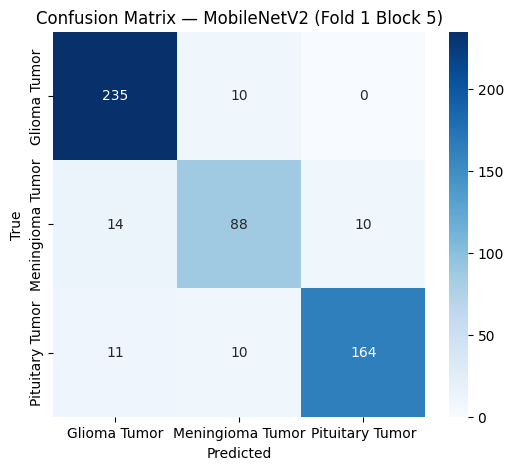

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,685,187
Non-trainable params: 542,528
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1361 - accuracy: 0.8402 | val_loss: 0.0943 - val_accuracy: 0.9170
val_accuracy improved from 0.0000 to 0.9170, saving weights to /kaggle/working/MobileNetV2_block_4_fold_1.pth


Epoch 2/50 | loss: 0.1115 - accuracy: 0.8632 | val_loss: 0.0930 - val_accuracy: 0.9096
val_accuracy did not improve from 0.9170


Epoch 3/50 | loss: 0.0976 - accuracy: 0.8779 | val_loss: 0.0836 - val_accuracy: 0.9225
val_accuracy improved from 0.9170 to 0.9225, saving weights to /kaggle/working/MobileNetV2_block_4_fold_1.pth


Epoch 4/50 | loss: 0.0922 - accuracy: 0.8894 | val_loss: 0.0925 - val_accuracy: 0.9059
val_accuracy did not improve from 0.9225


...

Epoch 11/50 | loss: 0.0610 - accuracy: 0.9239 | val_loss: 0.0736 - val_accuracy: 0.9151
val_accuracy did not improve from 0.9391


Epoch 12/50 | loss: 0.0630 - accuracy: 0.9179 | val_loss: 0.0628 - val_accuracy: 0.9280
val_accuracy did not improve from 0.9391


Epoch 13/50 | loss: 0.0578 - accuracy: 0.9259 | val_loss: 0.0601 - val_accuracy: 0.9391
val_accuracy did not improve from 0.9391


Epoch 14/50 | loss: 0.0597 - accuracy: 0.9259 | val_loss: 0.0566 - val_accuracy: 0.9391
val_accuracy did not improve from 0.9391


Epoch 15/50 | loss: 0.0569 - accuracy: 0.9302 | val_loss: 0.0598 - val_accuracy: 0.9373
val_accuracy did not improve from 0.9391
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.061898  0.939114
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.96       245
Meningioma Tumor       0.83      0.90      0.86       112
 Pituitary Tumor       1.00      0.94      0.97       185

        accuracy                           0.94       542
       macro avg       0.93      0.93      0.93       542
    weighted avg       0.94      0.94      0.94       542



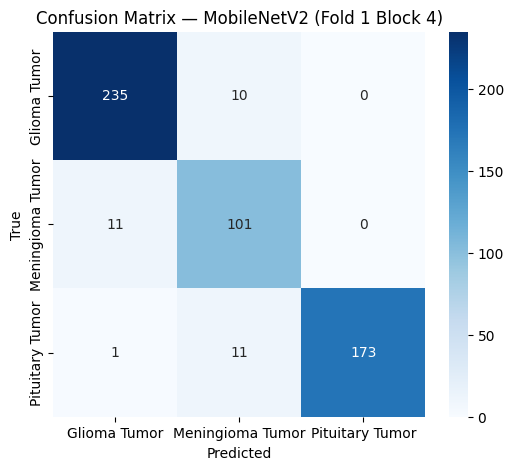

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.0673 - accuracy: 0.9183 | val_loss: 0.0623 - val_accuracy: 0.9317
val_accuracy improved from 0.0000 to 0.9317, saving weights to /kaggle/working/MobileNetV2_block_3_fold_1.pth


Epoch 2/50 | loss: 0.0668 - accuracy: 0.9140 | val_loss: 0.0592 - val_accuracy: 0.9410
val_accuracy improved from 0.9317 to 0.9410, saving weights to /kaggle/working/MobileNetV2_block_3_fold_1.pth


Epoch 3/50 | loss: 0.0592 - accuracy: 0.9251 | val_loss: 0.0758 - val_accuracy: 0.9004
val_accuracy did not improve from 0.9410


Epoch 4/50 | loss: 0.0628 - accuracy: 0.9247 | val_loss: 0.0828 - val_accuracy: 0.8911
val_accuracy did not improve from 0.9410


Epoch 5/50 | loss: 0.0564 - accuracy: 0.9294 | val_loss: 0.0664 - val_accuracy: 0.9244
val_accuracy did not improve from 0.9410


Epoch 6/50 | loss: 0.0564 - accuracy: 0.9278 | val_loss: 0.0588 - val_accuracy: 0.9391
val_accuracy did not improve from 0.9410


Epoch 7/50 | loss: 0.0506 - accuracy: 0.9385 | val_loss: 0.0551 - val_accuracy: 0.9410
val_accuracy did not improve from 0.9410


Epoch 8/50 | loss: 0.0474 - accuracy: 0.9409 | val_loss: 0.0731 - val_accuracy: 0.9133
val_accuracy did not improve from 0.9410
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.059241  0.940959
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.94      0.96       245
Meningioma Tumor       0.81      0.94      0.87       112
 Pituitary Tumor       0.99      0.94      0.97       185

        accuracy                           0.94       542
       macro avg       0.93      0.94      0.93       542
    weighted avg       0.95      0.94      0.94       542



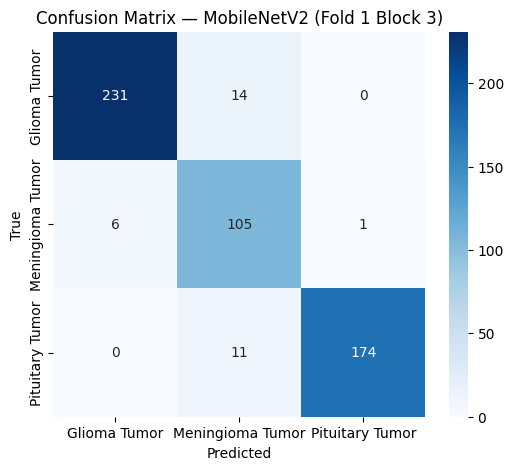

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0653 - accuracy: 0.9259 | val_loss: 0.0552 - val_accuracy: 0.9428
val_accuracy improved from 0.0000 to 0.9428, saving weights to /kaggle/working/MobileNetV2_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0573 - accuracy: 0.9251 | val_loss: 0.0462 - val_accuracy: 0.9446
val_accuracy improved from 0.9428 to 0.9446, saving weights to /kaggle/working/MobileNetV2_block_2_fold_1.pth


Epoch 3/50 | loss: 0.0605 - accuracy: 0.9243 | val_loss: 0.0603 - val_accuracy: 0.9373
val_accuracy did not improve from 0.9446


Epoch 4/50 | loss: 0.0477 - accuracy: 0.9417 | val_loss: 0.0507 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9446


...

Epoch 12/50 | loss: 0.0335 - accuracy: 0.9520 | val_loss: 0.0400 - val_accuracy: 0.9520
val_accuracy did not improve from 0.9631


Epoch 13/50 | loss: 0.0370 - accuracy: 0.9508 | val_loss: 0.0402 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9631


Epoch 14/50 | loss: 0.0338 - accuracy: 0.9560 | val_loss: 0.0461 - val_accuracy: 0.9483
val_accuracy did not improve from 0.9631


Epoch 15/50 | loss: 0.0336 - accuracy: 0.9572 | val_loss: 0.0428 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9631


Epoch 16/50 | loss: 0.0298 - accuracy: 0.9631 | val_loss: 0.0417 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9631
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.044305    0.9631
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.93      0.96       245
Meningioma Tumor       0.87      0.96      0.92       112
 Pituitary Tumor       0.99      1.00      0.99       185

        accuracy                           0.96       542
       macro avg       0.95      0.97      0.96       542
    weighted avg       0.97      0.96      0.96       542



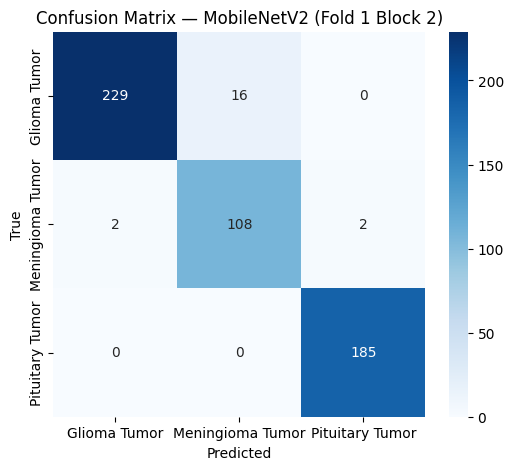

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0481 - accuracy: 0.9393 | val_loss: 0.0686 - val_accuracy: 0.9170
val_accuracy improved from 0.0000 to 0.9170, saving weights to /kaggle/working/MobileNetV2_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0445 - accuracy: 0.9500 | val_loss: 0.0425 - val_accuracy: 0.9557
val_accuracy improved from 0.9170 to 0.9557, saving weights to /kaggle/working/MobileNetV2_block_1_fold_1.pth


Epoch 3/50 | loss: 0.0399 - accuracy: 0.9492 | val_loss: 0.0395 - val_accuracy: 0.9668
val_accuracy improved from 0.9557 to 0.9668, saving weights to /kaggle/working/MobileNetV2_block_1_fold_1.pth


Epoch 4/50 | loss: 0.0324 - accuracy: 0.9592 | val_loss: 0.0661 - val_accuracy: 0.9170
val_accuracy did not improve from 0.9668


...

Epoch 11/50 | loss: 0.0203 - accuracy: 0.9754 | val_loss: 0.0413 - val_accuracy: 0.9613
val_accuracy did not improve from 0.9686


Epoch 12/50 | loss: 0.0204 - accuracy: 0.9730 | val_loss: 0.0420 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9686


Epoch 13/50 | loss: 0.0194 - accuracy: 0.9746 | val_loss: 0.0320 - val_accuracy: 0.9613
val_accuracy did not improve from 0.9686


Epoch 14/50 | loss: 0.0197 - accuracy: 0.9750 | val_loss: 0.0327 - val_accuracy: 0.9631
val_accuracy did not improve from 0.9686


Epoch 15/50 | loss: 0.0242 - accuracy: 0.9718 | val_loss: 0.0521 - val_accuracy: 0.9410
val_accuracy did not improve from 0.9686
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.032759  0.968635
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.97      0.97       245
Meningioma Tumor       0.91      0.96      0.93       112
 Pituitary Tumor       1.00      0.98      0.99       185

        accuracy                           0.97       542
       macro avg       0.96      0.97      0.96       542
    weighted avg       0.97      0.97      0.97       542



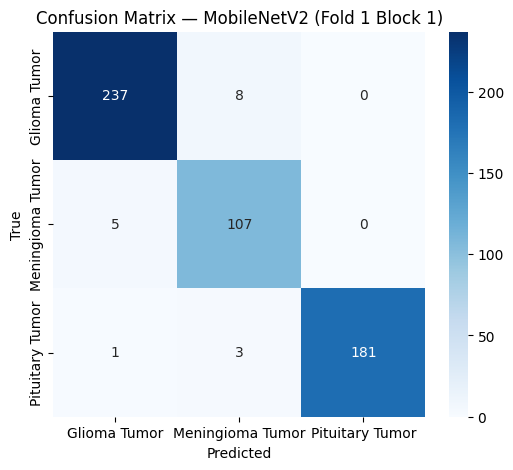

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4353 - accuracy: 0.5107 | val_loss: 0.3344 - val_accuracy: 0.6819
val_accuracy improved from 0.0000 to 0.6819, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


Epoch 2/50 | loss: 0.3218 - accuracy: 0.6784 | val_loss: 0.2737 - val_accuracy: 0.7231
val_accuracy improved from 0.6819 to 0.7231, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


Epoch 3/50 | loss: 0.2638 - accuracy: 0.7497 | val_loss: 0.2267 - val_accuracy: 0.7629
val_accuracy improved from 0.7231 to 0.7629, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


Epoch 4/50 | loss: 0.2335 - accuracy: 0.7669 | val_loss: 0.2094 - val_accuracy: 0.7717
val_accuracy improved from 0.7629 to 0.7717, saving weights to /kaggle/working/MobileNetV2_block_5_fold_2.pth


...

Epoch 9/50 | loss: 0.1723 - accuracy: 0.8256 | val_loss: 0.1690 - val_accuracy: 0.8027
val_accuracy did not improve from 0.8174


Epoch 10/50 | loss: 0.1670 - accuracy: 0.8281 | val_loss: 0.1751 - val_accuracy: 0.7835
val_accuracy did not improve from 0.8174


Epoch 11/50 | loss: 0.1669 - accuracy: 0.8226 | val_loss: 0.1671 - val_accuracy: 0.7909
val_accuracy did not improve from 0.8174


Epoch 12/50 | loss: 0.1620 - accuracy: 0.8306 | val_loss: 0.1631 - val_accuracy: 0.7982
val_accuracy did not improve from 0.8174


Epoch 13/50 | loss: 0.1573 - accuracy: 0.8340 | val_loss: 0.1611 - val_accuracy: 0.8012
val_accuracy did not improve from 0.8174
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.172603  0.817378
                  precision    recall  f1-score   support

    Glioma Tumor       0.83      0.89      0.86       338
Meningioma Tumor       0.71      0.58      0.64       167
 Pituitary Tumor       0.87      0.90      0.88       174

        accuracy                           0.82       679
       macro avg       0.80      0.79      0.79       679
    weighted avg       0.81      0.82      0.81       679



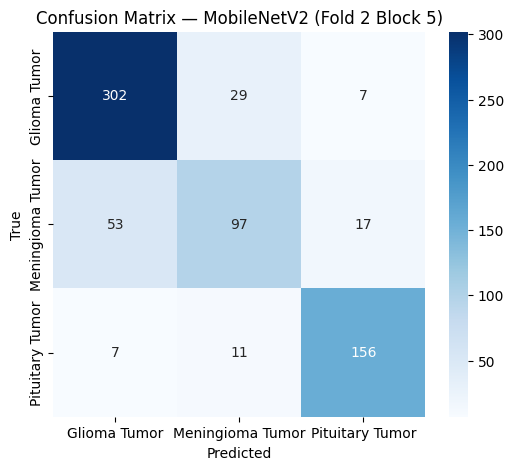

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,685,187
Non-trainable params: 542,528
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1561 - accuracy: 0.8294 | val_loss: 0.1346 - val_accuracy: 0.8380
val_accuracy improved from 0.0000 to 0.8380, saving weights to /kaggle/working/MobileNetV2_block_4_fold_2.pth


Epoch 2/50 | loss: 0.1238 - accuracy: 0.8616 | val_loss: 0.1452 - val_accuracy: 0.8144
val_accuracy did not improve from 0.8380


Epoch 3/50 | loss: 0.1179 - accuracy: 0.8679 | val_loss: 0.1473 - val_accuracy: 0.8189
val_accuracy did not improve from 0.8380


Epoch 4/50 | loss: 0.1014 - accuracy: 0.8834 | val_loss: 0.1168 - val_accuracy: 0.8586
val_accuracy improved from 0.8380 to 0.8586, saving weights to /kaggle/working/MobileNetV2_block_4_fold_2.pth


...

Epoch 11/50 | loss: 0.0707 - accuracy: 0.9170 | val_loss: 0.0995 - val_accuracy: 0.8837
val_accuracy did not improve from 0.8940


Epoch 12/50 | loss: 0.0626 - accuracy: 0.9270 | val_loss: 0.0937 - val_accuracy: 0.8895
val_accuracy did not improve from 0.8940


Epoch 13/50 | loss: 0.0572 - accuracy: 0.9262 | val_loss: 0.1028 - val_accuracy: 0.8837
val_accuracy did not improve from 0.8940


Epoch 14/50 | loss: 0.0616 - accuracy: 0.9279 | val_loss: 0.1114 - val_accuracy: 0.8689
val_accuracy did not improve from 0.8940


Epoch 15/50 | loss: 0.0607 - accuracy: 0.9262 | val_loss: 0.1004 - val_accuracy: 0.8910
val_accuracy did not improve from 0.8940
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.096383  0.893962
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.93      0.92       338
Meningioma Tumor       0.79      0.80      0.80       167
 Pituitary Tumor       0.96      0.91      0.93       174

        accuracy                           0.89       679
       macro avg       0.89      0.88      0.88       679
    weighted avg       0.89      0.89      0.89       679



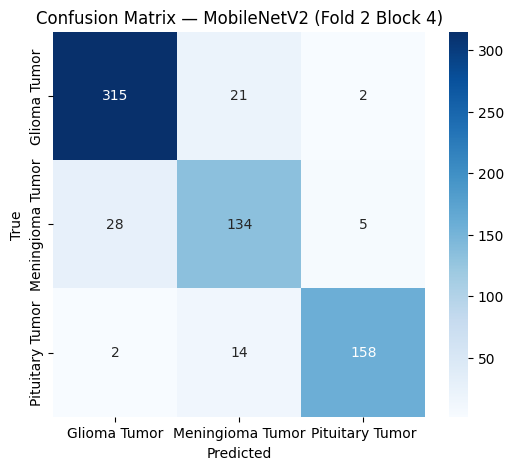

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.0753 - accuracy: 0.9094 | val_loss: 0.1046 - val_accuracy: 0.8822
val_accuracy improved from 0.0000 to 0.8822, saving weights to /kaggle/working/MobileNetV2_block_3_fold_2.pth


Epoch 2/50 | loss: 0.0608 - accuracy: 0.9266 | val_loss: 0.1026 - val_accuracy: 0.8895
val_accuracy improved from 0.8822 to 0.8895, saving weights to /kaggle/working/MobileNetV2_block_3_fold_2.pth


Epoch 3/50 | loss: 0.0659 - accuracy: 0.9191 | val_loss: 0.1091 - val_accuracy: 0.8704
val_accuracy did not improve from 0.8895


Epoch 4/50 | loss: 0.0609 - accuracy: 0.9283 | val_loss: 0.1011 - val_accuracy: 0.8837
val_accuracy did not improve from 0.8895


...

Epoch 13/50 | loss: 0.0364 - accuracy: 0.9530 | val_loss: 0.0983 - val_accuracy: 0.8940
val_accuracy did not improve from 0.9072


Epoch 14/50 | loss: 0.0340 - accuracy: 0.9577 | val_loss: 0.0938 - val_accuracy: 0.9057
val_accuracy did not improve from 0.9072


Epoch 15/50 | loss: 0.0305 - accuracy: 0.9610 | val_loss: 0.0960 - val_accuracy: 0.8999
val_accuracy did not improve from 0.9072


Epoch 16/50 | loss: 0.0320 - accuracy: 0.9593 | val_loss: 0.0913 - val_accuracy: 0.9057
val_accuracy did not improve from 0.9072


Epoch 17/50 | loss: 0.0329 - accuracy: 0.9581 | val_loss: 0.0895 - val_accuracy: 0.9072
val_accuracy did not improve from 0.9072
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.085883  0.907216
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.94      0.94       338
Meningioma Tumor       0.81      0.85      0.83       167
 Pituitary Tumor       0.96      0.90      0.93       174

        accuracy                           0.91       679
       macro avg       0.90      0.90      0.90       679
    weighted avg       0.91      0.91      0.91       679



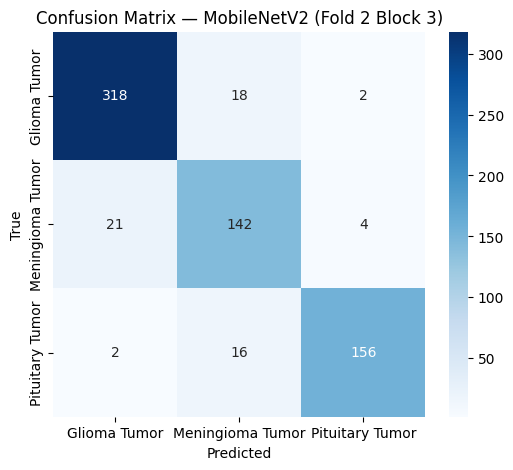

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0387 - accuracy: 0.9472 | val_loss: 0.0917 - val_accuracy: 0.8881
val_accuracy improved from 0.0000 to 0.8881, saving weights to /kaggle/working/MobileNetV2_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0365 - accuracy: 0.9509 | val_loss: 0.1163 - val_accuracy: 0.8792
val_accuracy did not improve from 0.8881


Epoch 3/50 | loss: 0.0346 - accuracy: 0.9572 | val_loss: 0.1142 - val_accuracy: 0.8807
val_accuracy did not improve from 0.8881


Epoch 4/50 | loss: 0.0361 - accuracy: 0.9535 | val_loss: 0.1051 - val_accuracy: 0.8969
val_accuracy improved from 0.8881 to 0.8969, saving weights to /kaggle/working/MobileNetV2_block_2_fold_2.pth


...

Epoch 14/50 | loss: 0.0196 - accuracy: 0.9736 | val_loss: 0.0749 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9234


Epoch 15/50 | loss: 0.0220 - accuracy: 0.9690 | val_loss: 0.0809 - val_accuracy: 0.9131
val_accuracy did not improve from 0.9234


Epoch 16/50 | loss: 0.0211 - accuracy: 0.9727 | val_loss: 0.0862 - val_accuracy: 0.9131
val_accuracy did not improve from 0.9234


Epoch 17/50 | loss: 0.0161 - accuracy: 0.9795 | val_loss: 0.1138 - val_accuracy: 0.9043
val_accuracy did not improve from 0.9234


Epoch 18/50 | loss: 0.0163 - accuracy: 0.9799 | val_loss: 0.0909 - val_accuracy: 0.9116
val_accuracy did not improve from 0.9234
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.075887  0.923417
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.95      0.94       338
Meningioma Tumor       0.87      0.86      0.86       167
 Pituitary Tumor       0.96      0.94      0.95       174

        accuracy                           0.92       679
       macro avg       0.92      0.92      0.92       679
    weighted avg       0.92      0.92      0.92       679



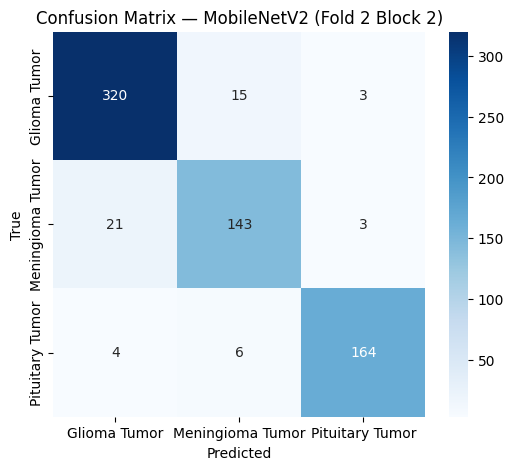

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0309 - accuracy: 0.9623 | val_loss: 0.0733 - val_accuracy: 0.9190
val_accuracy improved from 0.0000 to 0.9190, saving weights to /kaggle/working/MobileNetV2_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0191 - accuracy: 0.9782 | val_loss: 0.0958 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9190


Epoch 3/50 | loss: 0.0209 - accuracy: 0.9715 | val_loss: 0.0954 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9190


Epoch 4/50 | loss: 0.0145 - accuracy: 0.9836 | val_loss: 0.0872 - val_accuracy: 0.9264
val_accuracy improved from 0.9190 to 0.9264, saving weights to /kaggle/working/MobileNetV2_block_1_fold_2.pth


...

Epoch 6/50 | loss: 0.0122 - accuracy: 0.9849 | val_loss: 0.0884 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9264


Epoch 7/50 | loss: 0.0136 - accuracy: 0.9811 | val_loss: 0.0902 - val_accuracy: 0.9131
val_accuracy did not improve from 0.9264


Epoch 8/50 | loss: 0.0141 - accuracy: 0.9836 | val_loss: 0.0921 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9264


Epoch 9/50 | loss: 0.0124 - accuracy: 0.9820 | val_loss: 0.0885 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9264


Epoch 10/50 | loss: 0.0138 - accuracy: 0.9836 | val_loss: 0.0908 - val_accuracy: 0.9146
val_accuracy did not improve from 0.9264
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.087183  0.926362
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.94      0.94       338
Meningioma Tumor       0.85      0.89      0.87       167
 Pituitary Tumor       0.95      0.94      0.95       174

        accuracy                           0.93       679
       macro avg       0.92      0.92      0.92       679
    weighted avg       0.93      0.93      0.93       679



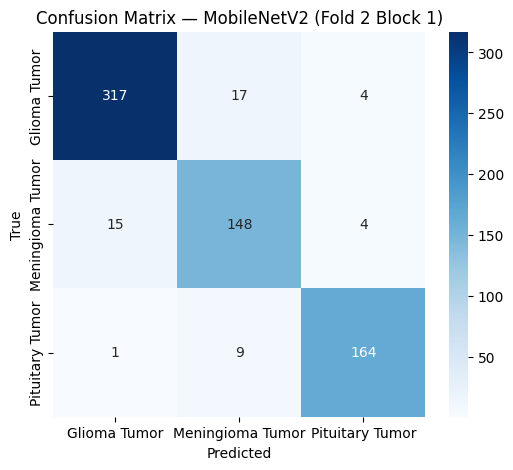

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4544 - accuracy: 0.4835 | val_loss: 0.3965 - val_accuracy: 0.4790
val_accuracy improved from 0.0000 to 0.4790, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


Epoch 2/50 | loss: 0.3311 - accuracy: 0.6461 | val_loss: 0.2979 - val_accuracy: 0.7483
val_accuracy improved from 0.4790 to 0.7483, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


Epoch 3/50 | loss: 0.2731 - accuracy: 0.7243 | val_loss: 0.2670 - val_accuracy: 0.7570
val_accuracy improved from 0.7483 to 0.7570, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


Epoch 4/50 | loss: 0.2393 - accuracy: 0.7588 | val_loss: 0.2325 - val_accuracy: 0.8094
val_accuracy improved from 0.7570 to 0.8094, saving weights to /kaggle/working/MobileNetV2_block_5_fold_3.pth


...

Epoch 10/50 | loss: 0.1704 - accuracy: 0.8230 | val_loss: 0.1818 - val_accuracy: 0.8269
val_accuracy did not improve from 0.8322


Epoch 11/50 | loss: 0.1682 - accuracy: 0.8295 | val_loss: 0.1916 - val_accuracy: 0.8024
val_accuracy did not improve from 0.8322


Epoch 12/50 | loss: 0.1646 - accuracy: 0.8278 | val_loss: 0.1779 - val_accuracy: 0.8199
val_accuracy did not improve from 0.8322


Epoch 13/50 | loss: 0.1692 - accuracy: 0.8218 | val_loss: 0.1766 - val_accuracy: 0.8182
val_accuracy did not improve from 0.8322


Epoch 14/50 | loss: 0.1475 - accuracy: 0.8379 | val_loss: 0.1718 - val_accuracy: 0.8304
val_accuracy did not improve from 0.8322
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.190407  0.832168
                  precision    recall  f1-score   support

    Glioma Tumor       0.82      0.85      0.84       231
Meningioma Tumor       0.69      0.67      0.68       139
 Pituitary Tumor       0.93      0.92      0.93       202

        accuracy                           0.83       572
       macro avg       0.82      0.81      0.82       572
    weighted avg       0.83      0.83      0.83       572



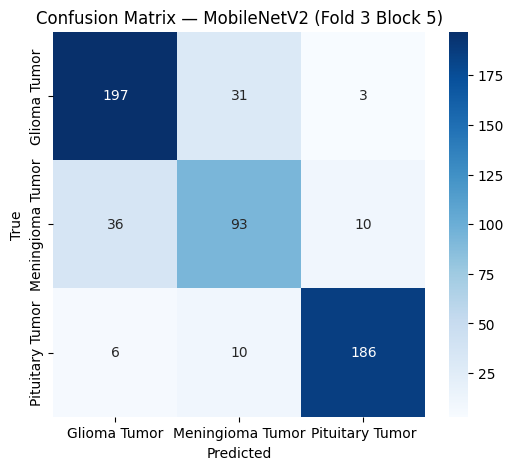

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,685,187
Non-trainable params: 542,528
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1477 - accuracy: 0.8303 | val_loss: 0.1688 - val_accuracy: 0.8007
val_accuracy improved from 0.0000 to 0.8007, saving weights to /kaggle/working/MobileNetV2_block_4_fold_3.pth


Epoch 2/50 | loss: 0.1249 - accuracy: 0.8587 | val_loss: 0.1408 - val_accuracy: 0.8497
val_accuracy improved from 0.8007 to 0.8497, saving weights to /kaggle/working/MobileNetV2_block_4_fold_3.pth


Epoch 3/50 | loss: 0.1093 - accuracy: 0.8780 | val_loss: 0.1233 - val_accuracy: 0.8724
val_accuracy improved from 0.8497 to 0.8724, saving weights to /kaggle/working/MobileNetV2_block_4_fold_3.pth


Epoch 4/50 | loss: 0.0977 - accuracy: 0.8909 | val_loss: 0.1197 - val_accuracy: 0.8584
val_accuracy did not improve from 0.8724


...

Epoch 7/50 | loss: 0.0838 - accuracy: 0.8997 | val_loss: 0.1154 - val_accuracy: 0.8601
val_accuracy did not improve from 0.8776


Epoch 8/50 | loss: 0.0773 - accuracy: 0.9057 | val_loss: 0.1162 - val_accuracy: 0.8584
val_accuracy did not improve from 0.8776


Epoch 9/50 | loss: 0.0742 - accuracy: 0.9129 | val_loss: 0.1077 - val_accuracy: 0.8706
val_accuracy did not improve from 0.8776


Epoch 10/50 | loss: 0.0657 - accuracy: 0.9201 | val_loss: 0.1178 - val_accuracy: 0.8566
val_accuracy did not improve from 0.8776


Epoch 11/50 | loss: 0.0660 - accuracy: 0.9254 | val_loss: 0.1128 - val_accuracy: 0.8689
val_accuracy did not improve from 0.8776
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.113746  0.877622
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.82      0.86       231
Meningioma Tumor       0.72      0.85      0.78       139
 Pituitary Tumor       0.97      0.97      0.97       202

        accuracy                           0.88       572
       macro avg       0.87      0.88      0.87       572
    weighted avg       0.89      0.88      0.88       572



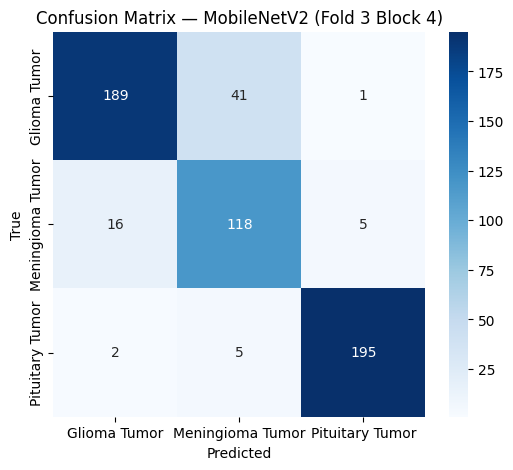

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.0902 - accuracy: 0.8965 | val_loss: 0.1101 - val_accuracy: 0.8724
val_accuracy improved from 0.0000 to 0.8724, saving weights to /kaggle/working/MobileNetV2_block_3_fold_3.pth


Epoch 2/50 | loss: 0.0743 - accuracy: 0.9121 | val_loss: 0.1234 - val_accuracy: 0.8601
val_accuracy did not improve from 0.8724


Epoch 3/50 | loss: 0.0714 - accuracy: 0.9117 | val_loss: 0.1153 - val_accuracy: 0.8636
val_accuracy did not improve from 0.8724


Epoch 4/50 | loss: 0.0661 - accuracy: 0.9185 | val_loss: 0.1114 - val_accuracy: 0.8759
val_accuracy improved from 0.8724 to 0.8759, saving weights to /kaggle/working/MobileNetV2_block_3_fold_3.pth


...

Epoch 9/50 | loss: 0.0529 - accuracy: 0.9322 | val_loss: 0.1102 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8829


Epoch 10/50 | loss: 0.0585 - accuracy: 0.9326 | val_loss: 0.1098 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8829


Epoch 11/50 | loss: 0.0511 - accuracy: 0.9398 | val_loss: 0.1097 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8829


Epoch 12/50 | loss: 0.0524 - accuracy: 0.9378 | val_loss: 0.1088 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8829


Epoch 13/50 | loss: 0.0491 - accuracy: 0.9438 | val_loss: 0.1079 - val_accuracy: 0.8759
val_accuracy did not improve from 0.8829
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.107296  0.882867
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.89      0.89       231
Meningioma Tumor       0.77      0.78      0.78       139
 Pituitary Tumor       0.95      0.95      0.95       202

        accuracy                           0.88       572
       macro avg       0.87      0.87      0.87       572
    weighted avg       0.88      0.88      0.88       572



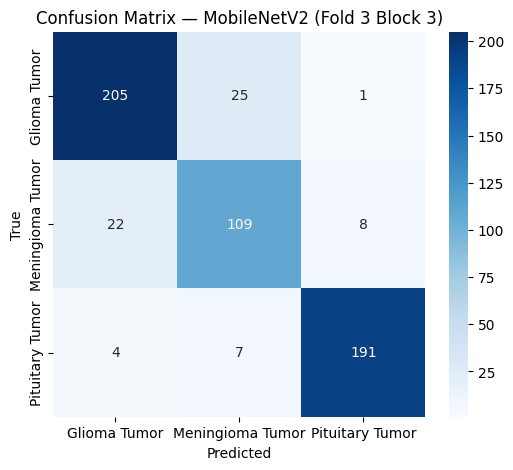

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0581 - accuracy: 0.9302 | val_loss: 0.1045 - val_accuracy: 0.8829
val_accuracy improved from 0.0000 to 0.8829, saving weights to /kaggle/working/MobileNetV2_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0508 - accuracy: 0.9330 | val_loss: 0.1147 - val_accuracy: 0.8741
val_accuracy did not improve from 0.8829


Epoch 3/50 | loss: 0.0530 - accuracy: 0.9366 | val_loss: 0.1147 - val_accuracy: 0.8724
val_accuracy did not improve from 0.8829


Epoch 4/50 | loss: 0.0485 - accuracy: 0.9370 | val_loss: 0.1045 - val_accuracy: 0.8899
val_accuracy improved from 0.8829 to 0.8899, saving weights to /kaggle/working/MobileNetV2_block_2_fold_3.pth


...

Epoch 16/50 | loss: 0.0194 - accuracy: 0.9767 | val_loss: 0.1063 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9196


Epoch 17/50 | loss: 0.0208 - accuracy: 0.9787 | val_loss: 0.1104 - val_accuracy: 0.9003
val_accuracy did not improve from 0.9196


Epoch 18/50 | loss: 0.0210 - accuracy: 0.9703 | val_loss: 0.1178 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9196


Epoch 19/50 | loss: 0.0172 - accuracy: 0.9787 | val_loss: 0.1121 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9196


Epoch 20/50 | loss: 0.0184 - accuracy: 0.9779 | val_loss: 0.1118 - val_accuracy: 0.9038
val_accuracy did not improve from 0.9196
early stopping, restoring model weights from the end of the best epoch
         Model     Loss  Accuracy
0  MobileNetV2  0.09848   0.91958
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.90      0.92       231
Meningioma Tumor       0.84      0.84      0.84       139
 Pituitary Tumor       0.95      1.00      0.97       202

        accuracy                           0.92       572
       macro avg       0.91      0.91      0.91       572
    weighted avg       0.92      0.92      0.92       572



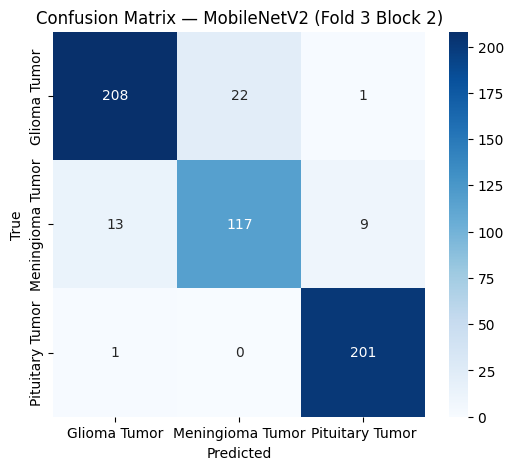

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0268 - accuracy: 0.9667 | val_loss: 0.1495 - val_accuracy: 0.8811
val_accuracy improved from 0.0000 to 0.8811, saving weights to /kaggle/working/MobileNetV2_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0226 - accuracy: 0.9723 | val_loss: 0.1488 - val_accuracy: 0.8776
val_accuracy did not improve from 0.8811


Epoch 3/50 | loss: 0.0254 - accuracy: 0.9687 | val_loss: 0.1110 - val_accuracy: 0.9003
val_accuracy improved from 0.8811 to 0.9003, saving weights to /kaggle/working/MobileNetV2_block_1_fold_3.pth


Epoch 4/50 | loss: 0.0172 - accuracy: 0.9795 | val_loss: 0.0997 - val_accuracy: 0.9126
val_accuracy improved from 0.9003 to 0.9126, saving weights to /kaggle/working/MobileNetV2_block_1_fold_3.pth


...

Epoch 6/50 | loss: 0.0224 - accuracy: 0.9727 | val_loss: 0.1658 - val_accuracy: 0.8864
val_accuracy did not improve from 0.9126


Epoch 7/50 | loss: 0.0171 - accuracy: 0.9767 | val_loss: 0.1008 - val_accuracy: 0.9021
val_accuracy did not improve from 0.9126


Epoch 8/50 | loss: 0.0154 - accuracy: 0.9799 | val_loss: 0.1344 - val_accuracy: 0.8969
val_accuracy did not improve from 0.9126


Epoch 9/50 | loss: 0.0162 - accuracy: 0.9819 | val_loss: 0.1035 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9126


Epoch 10/50 | loss: 0.0127 - accuracy: 0.9848 | val_loss: 0.1425 - val_accuracy: 0.8951
val_accuracy did not improve from 0.9126
early stopping, restoring model weights from the end of the best epoch
         Model     Loss  Accuracy
0  MobileNetV2  0.09965  0.912587
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.88      0.91       231
Meningioma Tumor       0.81      0.85      0.83       139
 Pituitary Tumor       0.96      1.00      0.98       202

        accuracy                           0.91       572
       macro avg       0.90      0.91      0.90       572
    weighted avg       0.91      0.91      0.91       572



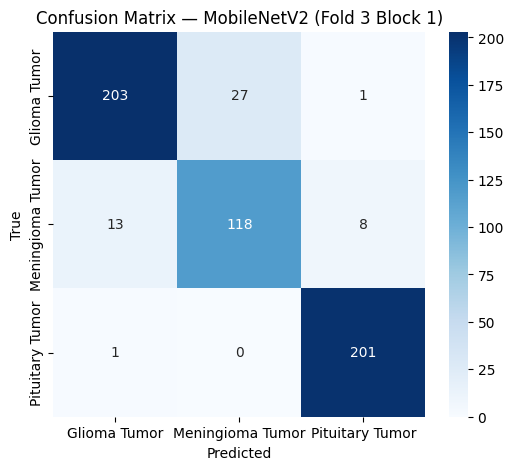

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4493 - accuracy: 0.4943 | val_loss: 0.3370 - val_accuracy: 0.6688
val_accuracy improved from 0.0000 to 0.6688, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


Epoch 2/50 | loss: 0.3289 - accuracy: 0.6695 | val_loss: 0.2654 - val_accuracy: 0.7643
val_accuracy improved from 0.6688 to 0.7643, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


Epoch 3/50 | loss: 0.2723 - accuracy: 0.7233 | val_loss: 0.2208 - val_accuracy: 0.8105
val_accuracy improved from 0.7643 to 0.8105, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


Epoch 4/50 | loss: 0.2463 - accuracy: 0.7545 | val_loss: 0.1951 - val_accuracy: 0.8408
val_accuracy improved from 0.8105 to 0.8408, saving weights to /kaggle/working/MobileNetV2_block_5_fold_4.pth


...

Epoch 28/50 | loss: 0.1369 - accuracy: 0.8481 | val_loss: 0.1011 - val_accuracy: 0.9061
val_accuracy did not improve from 0.9108


Epoch 29/50 | loss: 0.1415 - accuracy: 0.8543 | val_loss: 0.1010 - val_accuracy: 0.9029
val_accuracy did not improve from 0.9108


Epoch 30/50 | loss: 0.1333 - accuracy: 0.8477 | val_loss: 0.0992 - val_accuracy: 0.9108
val_accuracy did not improve from 0.9108


Epoch 31/50 | loss: 0.1320 - accuracy: 0.8518 | val_loss: 0.1001 - val_accuracy: 0.8981
val_accuracy did not improve from 0.9108


Epoch 32/50 | loss: 0.1363 - accuracy: 0.8555 | val_loss: 0.0985 - val_accuracy: 0.9061
val_accuracy did not improve from 0.9108
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.103049  0.910828
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.94      0.95       325
Meningioma Tumor       0.83      0.77      0.79       124
 Pituitary Tumor       0.90      0.95      0.92       179

        accuracy                           0.91       628
       macro avg       0.89      0.89      0.89       628
    weighted avg       0.91      0.91      0.91       628



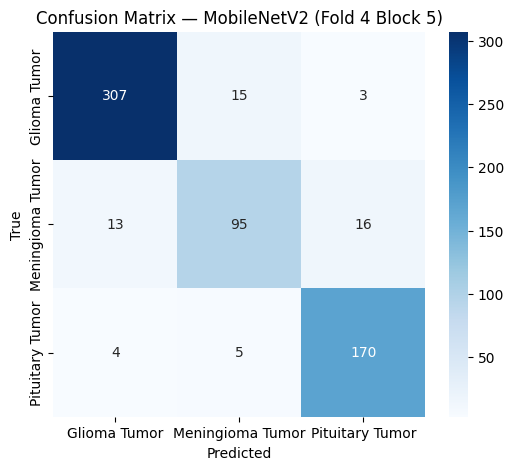

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,685,187
Non-trainable params: 542,528
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1336 - accuracy: 0.8436 | val_loss: 0.0873 - val_accuracy: 0.9076
val_accuracy improved from 0.0000 to 0.9076, saving weights to /kaggle/working/MobileNetV2_block_4_fold_4.pth


Epoch 2/50 | loss: 0.1144 - accuracy: 0.8678 | val_loss: 0.0841 - val_accuracy: 0.9124
val_accuracy improved from 0.9076 to 0.9124, saving weights to /kaggle/working/MobileNetV2_block_4_fold_4.pth


Epoch 3/50 | loss: 0.1005 - accuracy: 0.8748 | val_loss: 0.0824 - val_accuracy: 0.9029
val_accuracy did not improve from 0.9124


Epoch 4/50 | loss: 0.0946 - accuracy: 0.8904 | val_loss: 0.0848 - val_accuracy: 0.8981
val_accuracy did not improve from 0.9124


...

Epoch 7/50 | loss: 0.0766 - accuracy: 0.9039 | val_loss: 0.0713 - val_accuracy: 0.9236
val_accuracy did not improve from 0.9299


Epoch 8/50 | loss: 0.0809 - accuracy: 0.9085 | val_loss: 0.0658 - val_accuracy: 0.9268
val_accuracy did not improve from 0.9299


Epoch 9/50 | loss: 0.0792 - accuracy: 0.9044 | val_loss: 0.0630 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9299


Epoch 10/50 | loss: 0.0702 - accuracy: 0.9138 | val_loss: 0.0720 - val_accuracy: 0.9156
val_accuracy did not improve from 0.9299


Epoch 11/50 | loss: 0.0675 - accuracy: 0.9130 | val_loss: 0.0603 - val_accuracy: 0.9252
val_accuracy did not improve from 0.9299
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.068117  0.929936
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.95      0.96       325
Meningioma Tumor       0.83      0.84      0.84       124
 Pituitary Tumor       0.94      0.96      0.95       179

        accuracy                           0.93       628
       macro avg       0.91      0.91      0.91       628
    weighted avg       0.93      0.93      0.93       628



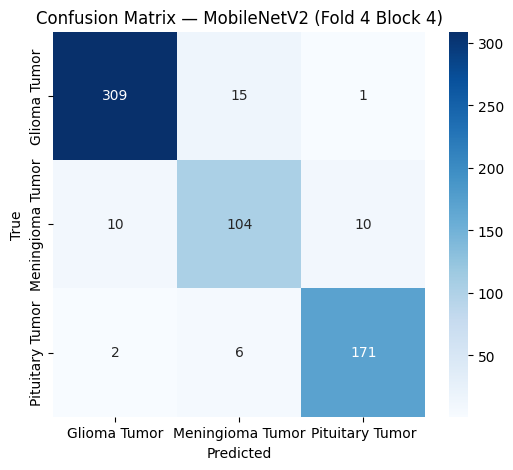

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.0872 - accuracy: 0.8982 | val_loss: 0.0808 - val_accuracy: 0.9092
val_accuracy improved from 0.0000 to 0.9092, saving weights to /kaggle/working/MobileNetV2_block_3_fold_4.pth


Epoch 2/50 | loss: 0.0799 - accuracy: 0.9039 | val_loss: 0.0668 - val_accuracy: 0.9283
val_accuracy improved from 0.9092 to 0.9283, saving weights to /kaggle/working/MobileNetV2_block_3_fold_4.pth


Epoch 3/50 | loss: 0.0749 - accuracy: 0.9052 | val_loss: 0.0620 - val_accuracy: 0.9299
val_accuracy improved from 0.9283 to 0.9299, saving weights to /kaggle/working/MobileNetV2_block_3_fold_4.pth


Epoch 4/50 | loss: 0.0740 - accuracy: 0.9097 | val_loss: 0.0591 - val_accuracy: 0.9315
val_accuracy improved from 0.9299 to 0.9315, saving weights to /kaggle/working/MobileNetV2_block_3_fold_4.pth


...

Epoch 13/50 | loss: 0.0439 - accuracy: 0.9446 | val_loss: 0.0684 - val_accuracy: 0.9188
val_accuracy did not improve from 0.9411


Epoch 14/50 | loss: 0.0402 - accuracy: 0.9470 | val_loss: 0.0567 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9411


Epoch 15/50 | loss: 0.0437 - accuracy: 0.9442 | val_loss: 0.0579 - val_accuracy: 0.9347
val_accuracy did not improve from 0.9411


Epoch 16/50 | loss: 0.0403 - accuracy: 0.9470 | val_loss: 0.0505 - val_accuracy: 0.9411
val_accuracy did not improve from 0.9411


Epoch 17/50 | loss: 0.0385 - accuracy: 0.9540 | val_loss: 0.0563 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9411
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.054453  0.941083
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.94      0.96       325
Meningioma Tumor       0.81      0.94      0.87       124
 Pituitary Tumor       0.97      0.94      0.95       179

        accuracy                           0.94       628
       macro avg       0.92      0.94      0.93       628
    weighted avg       0.95      0.94      0.94       628



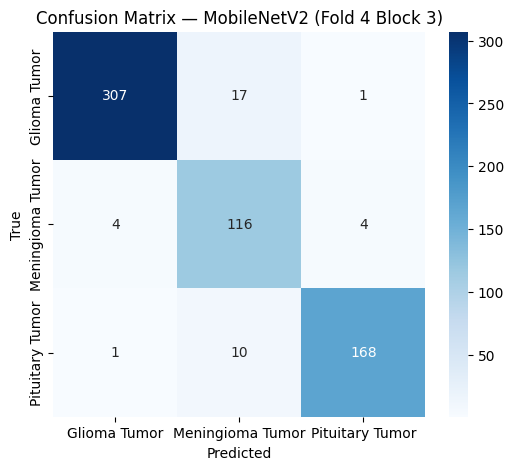

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0444 - accuracy: 0.9425 | val_loss: 0.0648 - val_accuracy: 0.9140
val_accuracy improved from 0.0000 to 0.9140, saving weights to /kaggle/working/MobileNetV2_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0484 - accuracy: 0.9392 | val_loss: 0.0605 - val_accuracy: 0.9188
val_accuracy improved from 0.9140 to 0.9188, saving weights to /kaggle/working/MobileNetV2_block_2_fold_4.pth


Epoch 3/50 | loss: 0.0417 - accuracy: 0.9483 | val_loss: 0.0464 - val_accuracy: 0.9363
val_accuracy improved from 0.9188 to 0.9363, saving weights to /kaggle/working/MobileNetV2_block_2_fold_4.pth


Epoch 4/50 | loss: 0.0399 - accuracy: 0.9499 | val_loss: 0.0496 - val_accuracy: 0.9411
val_accuracy improved from 0.9363 to 0.9411, saving weights to /kaggle/working/MobileNetV2_block_2_fold_4.pth


...

Epoch 13/50 | loss: 0.0208 - accuracy: 0.9725 | val_loss: 0.0482 - val_accuracy: 0.9411
val_accuracy did not improve from 0.9522


Epoch 14/50 | loss: 0.0229 - accuracy: 0.9704 | val_loss: 0.0480 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9522


Epoch 15/50 | loss: 0.0209 - accuracy: 0.9721 | val_loss: 0.0496 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9522


Epoch 16/50 | loss: 0.0211 - accuracy: 0.9725 | val_loss: 0.0487 - val_accuracy: 0.9411
val_accuracy did not improve from 0.9522


Epoch 17/50 | loss: 0.0224 - accuracy: 0.9700 | val_loss: 0.0488 - val_accuracy: 0.9427
val_accuracy did not improve from 0.9522
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.048914  0.952229
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.90      0.88      0.89       124
 Pituitary Tumor       0.97      0.95      0.96       179

        accuracy                           0.95       628
       macro avg       0.94      0.94      0.94       628
    weighted avg       0.95      0.95      0.95       628



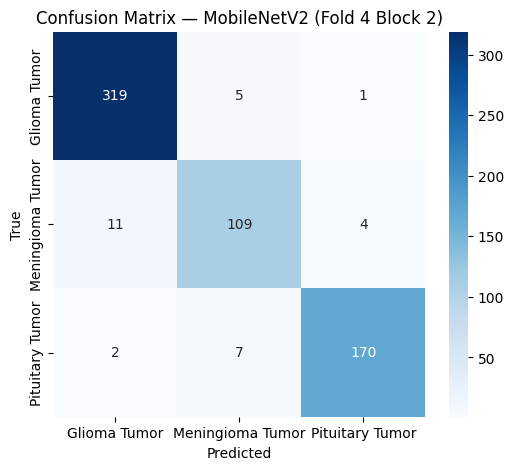

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0355 - accuracy: 0.9557 | val_loss: 0.0535 - val_accuracy: 0.9268
val_accuracy improved from 0.0000 to 0.9268, saving weights to /kaggle/working/MobileNetV2_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0286 - accuracy: 0.9647 | val_loss: 0.0523 - val_accuracy: 0.9395
val_accuracy improved from 0.9268 to 0.9395, saving weights to /kaggle/working/MobileNetV2_block_1_fold_4.pth


Epoch 3/50 | loss: 0.0346 - accuracy: 0.9553 | val_loss: 0.0549 - val_accuracy: 0.9475
val_accuracy improved from 0.9395 to 0.9475, saving weights to /kaggle/working/MobileNetV2_block_1_fold_4.pth


Epoch 4/50 | loss: 0.0288 - accuracy: 0.9626 | val_loss: 0.0549 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9475


...

Epoch 10/50 | loss: 0.0231 - accuracy: 0.9663 | val_loss: 0.0613 - val_accuracy: 0.9411
val_accuracy did not improve from 0.9586


Epoch 11/50 | loss: 0.0192 - accuracy: 0.9721 | val_loss: 0.0493 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9586


Epoch 12/50 | loss: 0.0156 - accuracy: 0.9799 | val_loss: 0.0685 - val_accuracy: 0.9363
val_accuracy did not improve from 0.9586


Epoch 13/50 | loss: 0.0150 - accuracy: 0.9799 | val_loss: 0.0547 - val_accuracy: 0.9475
val_accuracy did not improve from 0.9586


Epoch 14/50 | loss: 0.0126 - accuracy: 0.9869 | val_loss: 0.0597 - val_accuracy: 0.9443
val_accuracy did not improve from 0.9586
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.057388  0.958599
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.97      0.98       325
Meningioma Tumor       0.87      0.95      0.91       124
 Pituitary Tumor       0.99      0.94      0.97       179

        accuracy                           0.96       628
       macro avg       0.95      0.95      0.95       628
    weighted avg       0.96      0.96      0.96       628



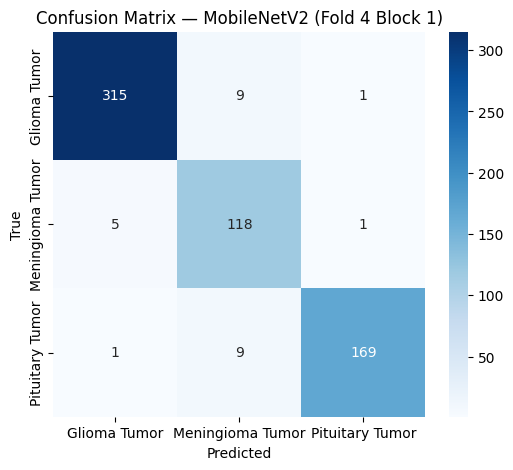

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     (2,223,872)          False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 3,843
Non-trainable params: 2,223,872
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass

Epoch 1/50 | loss: 0.4631 - accuracy: 0.4713 | val_loss: 0.3826 - val_accuracy: 0.6267
val_accuracy improved from 0.0000 to 0.6267, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


Epoch 2/50 | loss: 0.3176 - accuracy: 0.6803 | val_loss: 0.3109 - val_accuracy: 0.7185
val_accuracy improved from 0.6267 to 0.7185, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


Epoch 3/50 | loss: 0.2640 - accuracy: 0.7212 | val_loss: 0.2736 - val_accuracy: 0.7356
val_accuracy improved from 0.7185 to 0.7356, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


Epoch 4/50 | loss: 0.2306 - accuracy: 0.7732 | val_loss: 0.2463 - val_accuracy: 0.7807
val_accuracy improved from 0.7356 to 0.7807, saving weights to /kaggle/working/MobileNetV2_block_5_fold_5.pth


...

Epoch 30/50 | loss: 0.1145 - accuracy: 0.8765 | val_loss: 0.1682 - val_accuracy: 0.8196
val_accuracy did not improve from 0.8367


Epoch 31/50 | loss: 0.1139 - accuracy: 0.8653 | val_loss: 0.1716 - val_accuracy: 0.8243
val_accuracy did not improve from 0.8367


Epoch 32/50 | loss: 0.1181 - accuracy: 0.8732 | val_loss: 0.1745 - val_accuracy: 0.8196
val_accuracy did not improve from 0.8367


Epoch 33/50 | loss: 0.1151 - accuracy: 0.8703 | val_loss: 0.1665 - val_accuracy: 0.8227
val_accuracy did not improve from 0.8367


Epoch 34/50 | loss: 0.1135 - accuracy: 0.8765 | val_loss: 0.1688 - val_accuracy: 0.8196
val_accuracy did not improve from 0.8367
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.169191  0.836703
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.85      0.89       287
Meningioma Tumor       0.69      0.67      0.68       166
 Pituitary Tumor       0.84      0.96      0.90       190

        accuracy                           0.84       643
       macro avg       0.82      0.83      0.82       643
    weighted avg       0.84      0.84      0.84       643



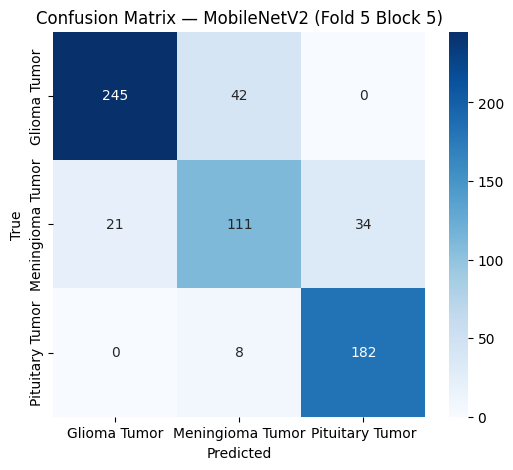

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,685,187
Non-trainable params: 542,528
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.1128 - accuracy: 0.8765 | val_loss: 0.1640 - val_accuracy: 0.8336
val_accuracy improved from 0.0000 to 0.8336, saving weights to /kaggle/working/MobileNetV2_block_4_fold_5.pth


Epoch 2/50 | loss: 0.0931 - accuracy: 0.8868 | val_loss: 0.1606 - val_accuracy: 0.8351
val_accuracy improved from 0.8336 to 0.8351, saving weights to /kaggle/working/MobileNetV2_block_4_fold_5.pth


Epoch 3/50 | loss: 0.0900 - accuracy: 0.8976 | val_loss: 0.1478 - val_accuracy: 0.8569
val_accuracy improved from 0.8351 to 0.8569, saving weights to /kaggle/working/MobileNetV2_block_4_fold_5.pth


Epoch 4/50 | loss: 0.0830 - accuracy: 0.9017 | val_loss: 0.1339 - val_accuracy: 0.8569
val_accuracy did not improve from 0.8569


...

Epoch 11/50 | loss: 0.0540 - accuracy: 0.9314 | val_loss: 0.1418 - val_accuracy: 0.8740
val_accuracy did not improve from 0.8771


Epoch 12/50 | loss: 0.0520 - accuracy: 0.9360 | val_loss: 0.1521 - val_accuracy: 0.8709
val_accuracy did not improve from 0.8771


Epoch 13/50 | loss: 0.0503 - accuracy: 0.9347 | val_loss: 0.1473 - val_accuracy: 0.8709
val_accuracy did not improve from 0.8771


Epoch 14/50 | loss: 0.0461 - accuracy: 0.9422 | val_loss: 0.1482 - val_accuracy: 0.8709
val_accuracy did not improve from 0.8771


Epoch 15/50 | loss: 0.0477 - accuracy: 0.9397 | val_loss: 0.1487 - val_accuracy: 0.8709
val_accuracy did not improve from 0.8771
early stopping, restoring model weights from the end of the best epoch
         Model    Loss  Accuracy
0  MobileNetV2  0.1393  0.877138
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.88      0.91       287
Meningioma Tumor       0.75      0.78      0.77       166
 Pituitary Tumor       0.89      0.96      0.92       190

        accuracy                           0.88       643
       macro avg       0.86      0.87      0.87       643
    weighted avg       0.88      0.88      0.88       643



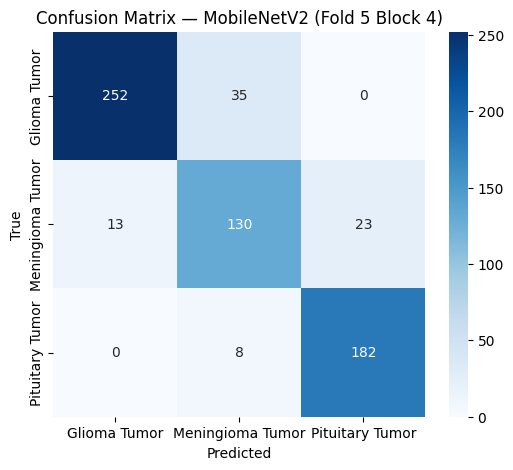

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 1,988,355
Non-trainable params: 239,360
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.0607 - accuracy: 0.9269 | val_loss: 0.1564 - val_accuracy: 0.8569
val_accuracy improved from 0.0000 to 0.8569, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0520 - accuracy: 0.9368 | val_loss: 0.1528 - val_accuracy: 0.8647
val_accuracy improved from 0.8569 to 0.8647, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


Epoch 3/50 | loss: 0.0522 - accuracy: 0.9327 | val_loss: 0.1312 - val_accuracy: 0.8787
val_accuracy improved from 0.8647 to 0.8787, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


Epoch 4/50 | loss: 0.0506 - accuracy: 0.9376 | val_loss: 0.1350 - val_accuracy: 0.8911
val_accuracy improved from 0.8787 to 0.8911, saving weights to /kaggle/working/MobileNetV2_block_3_fold_5.pth


...

Epoch 6/50 | loss: 0.0418 - accuracy: 0.9504 | val_loss: 0.1584 - val_accuracy: 0.8740
val_accuracy did not improve from 0.8911


Epoch 7/50 | loss: 0.0418 - accuracy: 0.9463 | val_loss: 0.1464 - val_accuracy: 0.8756
val_accuracy did not improve from 0.8911


Epoch 8/50 | loss: 0.0369 - accuracy: 0.9500 | val_loss: 0.1519 - val_accuracy: 0.8834
val_accuracy did not improve from 0.8911


Epoch 9/50 | loss: 0.0332 - accuracy: 0.9575 | val_loss: 0.1485 - val_accuracy: 0.8740
val_accuracy did not improve from 0.8911


Epoch 10/50 | loss: 0.0350 - accuracy: 0.9554 | val_loss: 0.1512 - val_accuracy: 0.8740
val_accuracy did not improve from 0.8911
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  MobileNetV2  0.134985  0.891135
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.92      0.93       287
Meningioma Tumor       0.80      0.77      0.78       166
 Pituitary Tumor       0.89      0.96      0.92       190

        accuracy                           0.89       643
       macro avg       0.88      0.88      0.88       643
    weighted avg       0.89      0.89      0.89       643



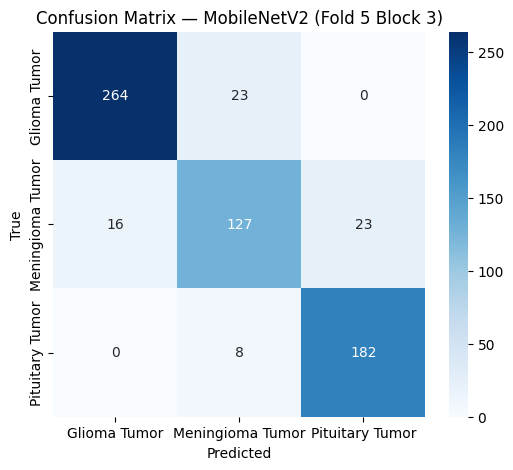

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,172,227
Non-trainable params: 55,488
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward p

Epoch 1/50 | loss: 0.0449 - accuracy: 0.9430 | val_loss: 0.1512 - val_accuracy: 0.8740
val_accuracy improved from 0.0000 to 0.8740, saving weights to /kaggle/working/MobileNetV2_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0442 - accuracy: 0.9430 | val_loss: 0.1666 - val_accuracy: 0.8694
val_accuracy did not improve from 0.8740


Epoch 3/50 | loss: 0.0419 - accuracy: 0.9459 | val_loss: 0.1476 - val_accuracy: 0.8802
val_accuracy improved from 0.8740 to 0.8802, saving weights to /kaggle/working/MobileNetV2_block_2_fold_5.pth


Epoch 4/50 | loss: 0.0369 - accuracy: 0.9546 | val_loss: 0.1648 - val_accuracy: 0.8709
val_accuracy did not improve from 0.8802


...

Epoch 13/50 | loss: 0.0194 - accuracy: 0.9752 | val_loss: 0.1706 - val_accuracy: 0.8896
val_accuracy did not improve from 0.8927


Epoch 14/50 | loss: 0.0211 - accuracy: 0.9703 | val_loss: 0.2126 - val_accuracy: 0.8756
val_accuracy did not improve from 0.8927


Epoch 15/50 | loss: 0.0243 - accuracy: 0.9694 | val_loss: 0.1759 - val_accuracy: 0.8896
val_accuracy did not improve from 0.8927


Epoch 16/50 | loss: 0.0152 - accuracy: 0.9847 | val_loss: 0.1709 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8927


Epoch 17/50 | loss: 0.0164 - accuracy: 0.9814 | val_loss: 0.2032 - val_accuracy: 0.8865
val_accuracy did not improve from 0.8927
early stopping, restoring model weights from the end of the best epoch
         Model     Loss  Accuracy
0  MobileNetV2  0.13806  0.892691
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.93      0.94       287
Meningioma Tumor       0.80      0.78      0.79       166
 Pituitary Tumor       0.89      0.94      0.92       190

        accuracy                           0.89       643
       macro avg       0.88      0.88      0.88       643
    weighted avg       0.89      0.89      0.89       643



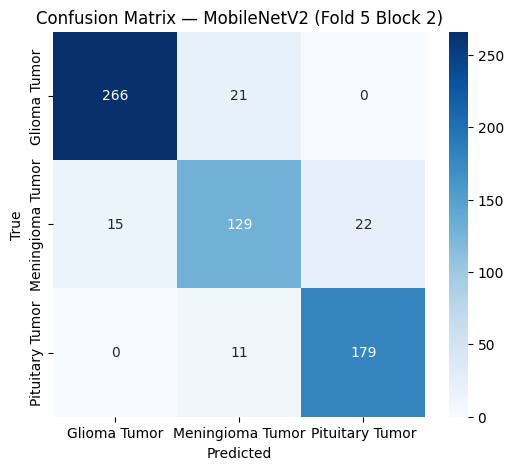

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     2,223,872            True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 1280, 7, 7]     [32, 1280, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 1280, 1, 1]     [32, 1280]           --                   --
├─Dropout (dropout)                           [32, 1280]           [32, 1280]           --                   --
├─Linear (classifier)                         [32, 1280]           [32, 3]              3,843                True
Total params: 2,227,715
Trainable params: 2,227,715
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 9.59
Input size (MB): 19.27
Forward/backward pass size (M

Epoch 1/50 | loss: 0.0292 - accuracy: 0.9674 | val_loss: 0.1564 - val_accuracy: 0.8834
val_accuracy improved from 0.0000 to 0.8834, saving weights to /kaggle/working/MobileNetV2_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0256 - accuracy: 0.9682 | val_loss: 0.1816 - val_accuracy: 0.8927
val_accuracy improved from 0.8834 to 0.8927, saving weights to /kaggle/working/MobileNetV2_block_1_fold_5.pth


Epoch 3/50 | loss: 0.0226 - accuracy: 0.9707 | val_loss: 0.2177 - val_accuracy: 0.8865
val_accuracy did not improve from 0.8927


Epoch 4/50 | loss: 0.0325 - accuracy: 0.9608 | val_loss: 0.1807 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8927


...

Epoch 7/50 | loss: 0.0168 - accuracy: 0.9814 | val_loss: 0.1743 - val_accuracy: 0.8849
val_accuracy did not improve from 0.8942


Epoch 8/50 | loss: 0.0145 - accuracy: 0.9798 | val_loss: 0.1805 - val_accuracy: 0.8927
val_accuracy did not improve from 0.8942


Epoch 9/50 | loss: 0.0146 - accuracy: 0.9802 | val_loss: 0.1792 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8942


Epoch 10/50 | loss: 0.0131 - accuracy: 0.9851 | val_loss: 0.1742 - val_accuracy: 0.8896
val_accuracy did not improve from 0.8942


Epoch 11/50 | loss: 0.0139 - accuracy: 0.9802 | val_loss: 0.1733 - val_accuracy: 0.8911
val_accuracy did not improve from 0.8942
early stopping, restoring model weights from the end of the best epoch
         Model    Loss  Accuracy
0  MobileNetV2  0.1906  0.894246
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.91      0.93       287
Meningioma Tumor       0.82      0.76      0.79       166
 Pituitary Tumor       0.87      0.98      0.92       190

        accuracy                           0.89       643
       macro avg       0.88      0.89      0.88       643
    weighted avg       0.89      0.89      0.89       643



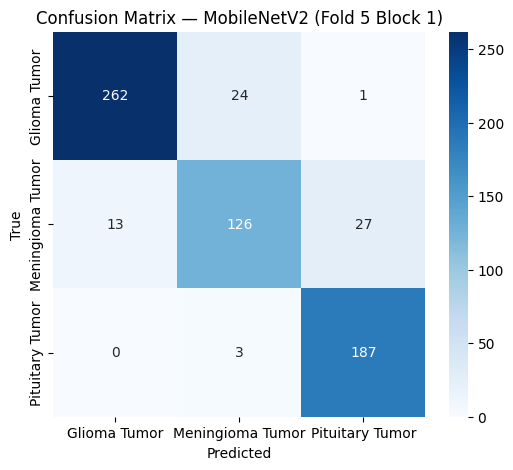

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5 = [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 5')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b5.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(4, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {5 - _} - block 5: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 5 - block 5: 85.91%
Accuracy unfreeze block 4 - block 5: 90.36%
Accuracy unfreeze block 3 - block 5: 91.27%
Accuracy unfreeze block 2 - block 5: 93.02%
Accuracy unfreeze block 1 - block 5: 93.21%
